In [40]:
import pickle
from backtesting import Backtest, Strategy
from backtesting.lib import crossover
from backtesting.test import SMA

import yfinance as yf
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.models import load_model
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

In [267]:
google = yf.download(tickers="1301.T", start="2004-08-19", end="2019-12-19", interval="1d")

C:\Users\togen\AppData\Local\Temp\ipykernel_20072\1590976857.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  google = yf.download(tickers="1301.T", start="2004-08-19", end="2019-12-19", interval="1d")
[*********************100%***********************]  1 of 1 completed


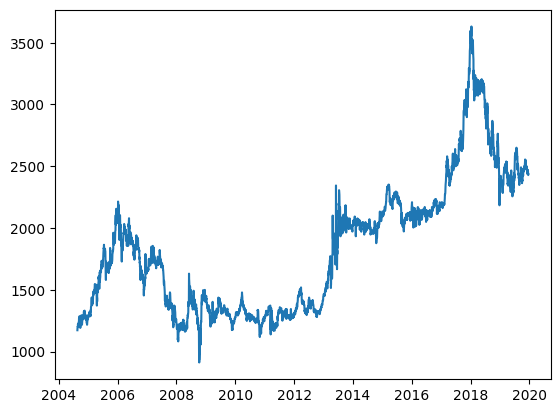

In [268]:
plt.plot(google["Open"])
plt.show()

In [269]:
google = google.drop(columns=['Volume']).reset_index()

In [270]:
google.columns = ['Date', 'Open', 'High', 'Low', 'Close']

In [271]:
google

,Date,Open,High,Low,Close
0,2004-08-19,1179.495972,1185.837348,1166.813219,1173.154595
1,2004-08-20,1192.178833,1211.202963,1179.496079,1185.837456
2,2004-08-23,1198.520020,1211.202771,1198.520020,1204.861395
3,2004-08-24,1198.520020,1204.861395,1198.520020,1204.861395
4,2004-08-25,1217.544189,1217.544189,1198.520061,1198.520061
...,...,...,...,...,...
3806,2019-12-12,2439.780273,2450.006387,2438.928097,2447.449859
3807,2019-12-13,2430.406250,2471.310703,2430.406250,2470.458527
3808,2019-12-16,2435.519043,2447.449507,2432.962515,2445.745155
3809,2019-12-17,2431.258301,2438.927885,2427.849597,2428.701773


In [272]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_google = scaler.fit_transform(google[["Open"]])
# scaled_nke = scaler.fit_transform(nke[["Open"]])

In [273]:
look_back = 60  # 過去60日から次の日を予測

# データ準備
X, y = [], []
for i in range(look_back, len(scaled_google)):
    X.append(scaled_google[i-look_back:i, 0])  # 直近60日のデータ
    y.append(scaled_google[i, 0])              # 翌日

X, y = np.array(X), np.array(y)

# 学習データ・テストデータに分割
train_range = int(len(X) * 0.8)
X_train, X_test = X[:train_range], X[train_range-look_back:]
y_train, y_test = y[:train_range], y[train_range-look_back:]

# LSTM用に3次元化
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test  = np.reshape(X_test,  (X_test.shape[0],  X_test.shape[1],  1))

print(X_train.shape)  # 例: (2000, 60, 1)

(3000, 60, 1)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
RMSE: 51.41835699513078


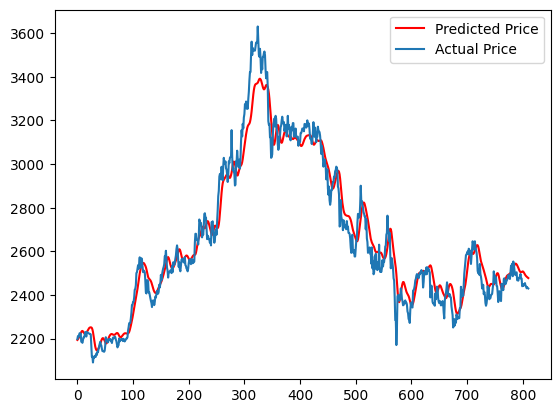

In [274]:
epochs = 30
simple_LSTM = None
model = pickle.load(open(Path("../model/simple_LSTM/GOOGL/simple_LSTM_30.pkl"), "rb"))

Observations = y_test
Predictions = model.predict(X_test)

rmse = np.sqrt(np.mean((pred - Observations) ** 2))
print(f"RMSE: {rmse}")

Observations = scaler.inverse_transform(Observations.reshape(-1, 1))
pred = scaler.inverse_transform(Predictions)

# グラフで予測値と実際の価格を比較
plt.plot(pred, color='red', label='Predicted Price')
plt.plot(Observations, label='Actual Price')
plt.legend()
plt.show()

In [266]:
rmse = np.sqrt(np.mean((pred - Observations) ** 2))
print(f"RMSE: {rmse}")

RMSE: 1.873179282855787


In [ ]:
pred_return = pd.DataFrame(pred) / pd.DataFrame(Observations) - 1

In [29]:
pred_return

,0
0,0.014634
1,0.017629
2,0.019922
3,0.013603
4,0.006721
...,...
816,-0.068474
817,-0.063961
818,-0.070754
819,-0.064519


In [228]:
google_test = pd.DataFrame({
    "Date": google["Date"][len(google) - len(Observations):].values,
    "Open": Observations.flatten(),
    "Close": google["Close"][len(google) - len(Observations):].values,
    "High": google["High"][len(google) - len(Observations):].values,
    "Low": google["Low"][len(google) - len(Observations):].values,
    "pred_open": pred.flatten(),
    "pred_return": pred_return.values.flatten()
})

In [229]:
google_test

,Date,Open,Close,High,Low,pred_open,pred_return
0,2016-09-15,39.787083,39.229925,39.907252,39.162886,40.369316,0.014634
1,2016-09-16,39.625202,39.677344,39.677344,39.409193,40.323750,0.017629
2,2016-09-19,39.497086,39.781126,39.924140,39.406213,40.283936,0.019922
3,2016-09-20,39.715080,39.726006,39.862565,39.639601,40.255325,0.013603
4,2016-09-21,39.975784,39.788576,40.019485,39.528866,40.244473,0.006721
...,...,...,...,...,...,...,...
816,2019-12-12,66.962654,66.700463,67.265065,66.451682,62.377445,-0.068474
817,2019-12-13,66.882202,66.933348,67.104667,66.623488,62.604321,-0.063961
818,2019-12-16,67.568977,67.285926,67.709503,67.067932,62.788193,-0.070754
819,2019-12-17,67.280464,67.653888,67.749231,67.075874,62.939579,-0.064519


In [230]:
google_test.reset_index(drop=True, inplace=True)
google_test.set_index('Date', inplace=True)

In [231]:
google_test

,Open,Close,High,Low,pred_open,pred_return
Date,,,,,,
2016-09-15,39.787083,39.229925,39.907252,39.162886,40.369316,0.014634
2016-09-16,39.625202,39.677344,39.677344,39.409193,40.323750,0.017629
2016-09-19,39.497086,39.781126,39.924140,39.406213,40.283936,0.019922
2016-09-20,39.715080,39.726006,39.862565,39.639601,40.255325,0.013603
2016-09-21,39.975784,39.788576,40.019485,39.528866,40.244473,0.006721
...,...,...,...,...,...,...
2019-12-12,66.962654,66.700463,67.265065,66.451682,62.377445,-0.068474
2019-12-13,66.882202,66.933348,67.104667,66.623488,62.604321,-0.063961
2019-12-16,67.568977,67.285926,67.709503,67.067932,62.788193,-0.070754


In [232]:
google_test['pred_return'].describe()

count    821.000000
mean      -0.011504
std        0.030805
min       -0.102131
25%       -0.035512
50%       -0.012122
75%        0.010581
max        0.104078
Name: pred_return, dtype: float64

In [233]:
print(len(google_test[google_test['pred_return'] > 0] == True))
print(len(google_test[google_test['pred_return'] <= 0] == True))

300
521


In [234]:
sell_flag = False

In [264]:
class simpleLSTMStrategy(Strategy):
    def init(self):
        # pred_return を indicator として登録
        self.pred_ret = self.I(lambda x: x, self.data.pred_return)
        self.open_price = self.I(lambda x: x, self.data.pred_open)
        self.pred_open = self.data.pred_open
        # フラグはインスタンス変数として管理する
        self.sell_flag = False

    def next(self):
        predicted_return = self.pred_ret[-1]
        opening_price = self.data.Open[-1]
        predicted_open_price = self.open_price[-1]

        # print(self.position)
            
        # ロングエントリー
        if predicted_open_price > opening_price:
            # if not self.position:
                self.buy(size=100)
                # self.sell_flag = True  # インスタンス変数として更新

        # ロング手仕舞い
        elif predicted_open_price < opening_price:
            # if self.position:
                self.position.close()
                # self.sell_flag = False  # インスタンス変数として更新

In [265]:
bt = Backtest(google_test[google_test.notna().all(axis=1)], simpleLSTMStrategy, cash=10000, commission=0.001)
result = bt.run()
print(result)
bt.plot()

Start                     2016-09-15 00:00:00
End                       2019-12-18 00:00:00
Duration                   1189 days 00:00:00
Exposure Time [%]                    42.63094
Equity Final [$]                  12980.01558
Equity Peak [$]                   13079.33823
Commissions [$]                     873.20631
Return [%]                           29.80016
Buy & Hold Return [%]                71.76998
Return (Ann.) [%]                     8.33505
Volatility (Ann.) [%]                14.17172
CAGR [%]                              5.68367
Sharpe Ratio                          0.58815
Sortino Ratio                         0.92129
Calmar Ratio                          0.87054
Alpha [%]                             4.16768
Beta                                  0.35715
Max. Drawdown [%]                    -9.57459
Avg. Drawdown [%]                     -2.3301
Max. Drawdown Duration      241 days 00:00:00
Avg. Drawdown Duration       40 days 00:00:00
# Trades                          

GridPlot(id='p43133', ...)

In [149]:
class SMAStrategy(Strategy):
    ns = 5
    nl = 25

    def init(self):
        self.smaS = self.I(SMA, self.data.Open, self.ns)
        self.smaL = self.I(SMA, self.data.Open, self.nl)

    def next(self):
        if crossover(self.smaS, self.smaL):
            if not self.position:
                self.buy(size=100)
        elif crossover(self.smaL, self.smaS):
            if self.position:
                self.sell(size=100)

In [118]:
bt_sma = Backtest(google_test.fillna(0), SMAStrategy, cash=10000, commission=0.001)
result = bt_sma.run()
print(result)
bt_sma.plot()

c:\Users\togen\FINAL_PAPER\research_using_uv\.venv310\lib\site-packages\backtesting\backtesting.py:168: RuntimeWarning: divide by zero encountered in divide
  x = value / self._data.Close
C:\Users\togen\AppData\Local\Temp\ipykernel_20072\3746852624.py:2: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  result = bt_sma.run()


Start                     2016-09-15 00:00:00
End                       2019-12-18 00:00:00
Duration                   1189 days 00:00:00
Exposure Time [%]                    57.61267
Equity Final [$]                   3526.97235
Equity Peak [$]                   10819.06153
Commissions [$]                     212.19611
Return [%]                          -64.73028
Buy & Hold Return [%]                     NaN
Return (Ann.) [%]                   -27.37631
Volatility (Ann.) [%]             14531.83213
CAGR [%]                            -19.81833
Sharpe Ratio                         -0.00188
Sortino Ratio                        -0.19968
Calmar Ratio                         -0.40617
Alpha [%]                                 NaN
Beta                                      NaN
Max. Drawdown [%]                   -67.40039
Avg. Drawdown [%]                   -48.92108
Max. Drawdown Duration      660 days 00:00:00
Avg. Drawdown Duration      208 days 00:00:00
# Trades                          

GridPlot(id='p16911', ...)